# exp000_eda

Initial EDA for BirdCLEF 2026.

Goals:
- confirm dataset shape
- inspect target labels
- check class imbalance
- listen to a few recordings
- compare waveform and spectrogram structure
- capture domain notes that may matter later

In [1]:
from pathlib import Path
import ast
import random

import IPython.display as ipd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
random.seed(42)

ROOT = Path.cwd().resolve()
if ROOT.name == "exp000_eda":
    ROOT = ROOT.parents[1]
elif not (ROOT / "train.csv").exists():
    raise FileNotFoundError("Run this notebook from the repository root or experiments/exp000_eda.")

ROOT

PosixPath('/Users/shionsuio/Downloads/BirdCLEF 2026')

In [2]:
train = pd.read_csv(ROOT / "train.csv")
taxonomy = pd.read_csv(ROOT / "taxonomy.csv")
soundscape_labels = pd.read_csv(ROOT / "train_soundscapes_labels.csv")
sample_submission = pd.read_csv(ROOT / "sample_submission.csv")

target_labels = pd.Index(sample_submission.columns[1:], name="primary_label")

print("train rows:", len(train))
print("taxonomy rows:", len(taxonomy))
print("soundscape label rows:", len(soundscape_labels))
print("submission targets:", len(target_labels))

train rows: 35549
taxonomy rows: 234
soundscape label rows: 1478
submission targets: 234


In [3]:
train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [4]:
summary = pd.DataFrame({
    "train_unique_primary_label": [train["primary_label"].nunique()],
    "submission_targets": [len(target_labels)],
    "train_not_in_submission": [len(set(train["primary_label"]) - set(target_labels))],
    "submission_not_in_train": [len(set(target_labels) - set(train["primary_label"]))],
})
summary

,train_unique_primary_label,submission_targets,train_not_in_submission,submission_not_in_train
0,206,234,0,28


In [5]:
label_counts = train["primary_label"].value_counts().rename_axis("primary_label").reset_index(name="count")
label_counts.head(20)

,primary_label,count
0,rubthr1,499
1,banana,498
2,fepowl,497
3,soulap1,497
4,houspa,496
5,coffal1,495
6,osprey,495
7,socfly1,494
8,compau,493
9,yeofly1,493


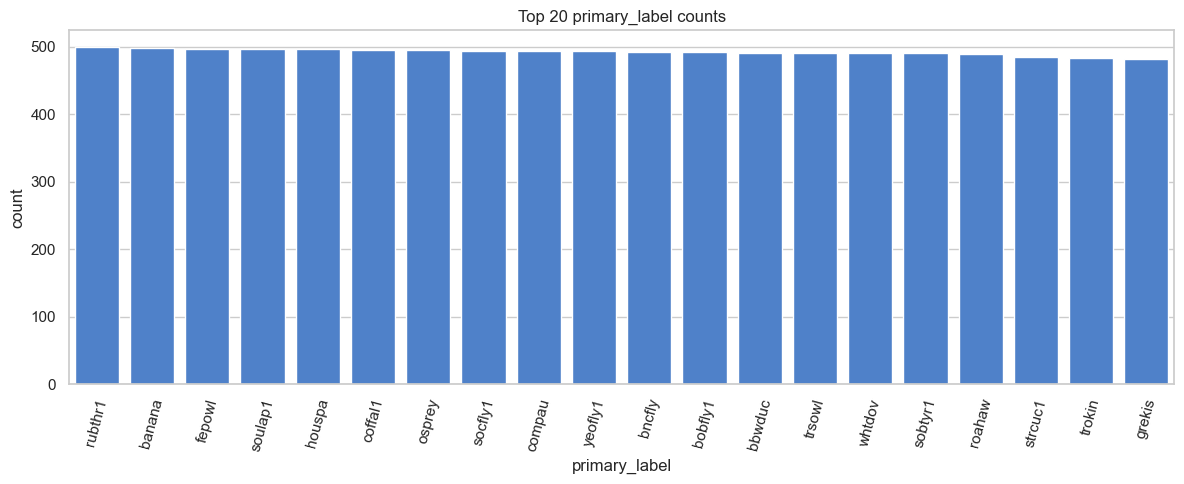

In [6]:
ax = sns.barplot(data=label_counts.head(20), x="primary_label", y="count", color="#3b7ddd")
ax.set_title("Top 20 primary_label counts")
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()

In [7]:
train[["type", "rating"]].describe(include="all")

,type,rating
count,35549,35549.000000
unique,755,NaN
top,[],NaN
freq,12975,NaN
mean,NaN,2.600748
std,NaN,2.070471
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,3.500000
75%,NaN,4.500000


In [8]:
secondary_count = (
    train["secondary_labels"]
    .fillna("[]")
    .map(lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 0)
)

secondary_count.describe()

count    35549.000000
mean         0.209035
std          0.692305
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         15.000000
Name: secondary_labels, dtype: float64

## Audio inspection helpers

In [9]:
taxonomy_lookup = taxonomy.set_index("primary_label")


def sample_recording(label: str, index: int = 0) -> pd.Series:
    rows = train.loc[train["primary_label"] == label].reset_index(drop=True)
    if rows.empty:
        raise ValueError(f"Unknown label: {label}")
    return rows.iloc[index % len(rows)]


def audio_path(row: pd.Series) -> Path:
    return ROOT / "train_audio" / row["filename"]


def load_audio(path: Path, offset: float = 0.0, duration: float = 10.0):
    info = sf.info(path)
    start_frame = int(offset * info.samplerate)
    num_frames = int(duration * info.samplerate)
    y, sr = sf.read(path, start=start_frame, frames=num_frames, dtype="float32")
    if getattr(y, "ndim", 1) == 2:
        y = y.mean(axis=1)
    return y, sr


def inspect_recording(label: str, index: int = 0, offset: float = 0.0, duration: float = 10.0) -> pd.Series:
    row = sample_recording(label, index=index)
    path = audio_path(row)
    y, sr = load_audio(path, offset=offset, duration=duration)

    display(row[["primary_label", "scientific_name", "common_name", "type", "rating", "secondary_labels"]])
    print(path)
    display(ipd.Audio(y, rate=sr))

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color="#2d6a4f")
    axes[0].set_title(f"Waveform: {label}")

    spec = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)
    librosa.display.specshow(spec, sr=sr, x_axis="time", y_axis="mel", ax=axes[1], cmap="magma")
    axes[1].set_title(f"Mel spectrogram: {label}")
    plt.tight_layout()
    return row

primary_label                 banana
scientific_name     Coereba flaveola
common_name               Bananaquit
type                        ['song']
rating                           1.0
secondary_labels                  []
Name: 0, dtype: object

/Users/shionsuio/Downloads/BirdCLEF 2026/train_audio/banana/XC178622.ogg


primary_label                                       banana
secondary_labels                                        []
type                                              ['song']
latitude                                            7.0974
longitude                                         -73.4457
scientific_name                           Coereba flaveola
common_name                                     Bananaquit
class_name                                            Aves
inat_taxon_id                                        10199
author                                      Oswaldo Cortes
license                                           by-nc-sa
rating                                                 1.0
url                 https://xeno-canto.org/178622/download
filename                               banana/XC178622.ogg
collection                                              XC
Name: 0, dtype: object

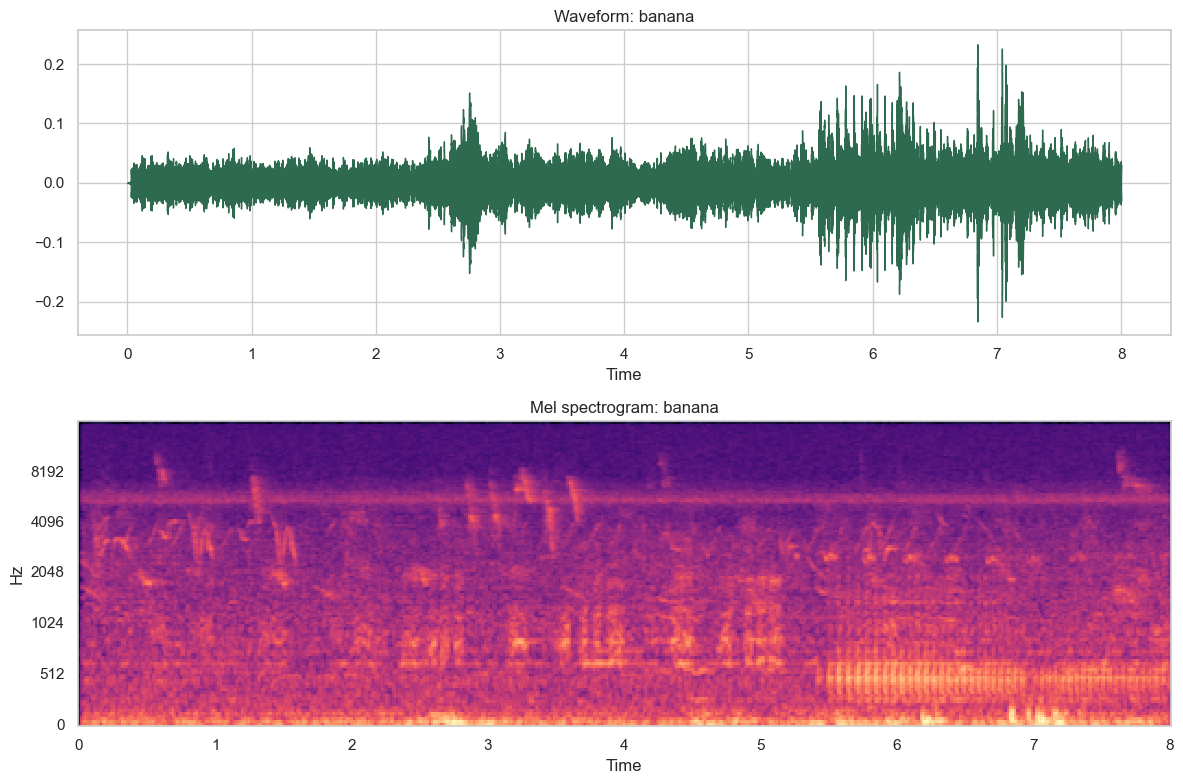

In [10]:
inspect_recording("banana", index=0, duration=8.0)

primary_label                     rubthr1
scientific_name        Turdus rufiventris
common_name         Rufous-bellied Thrush
type                             ['song']
rating                                3.0
secondary_labels                       []
Name: 0, dtype: object

/Users/shionsuio/Downloads/BirdCLEF 2026/train_audio/rubthr1/XC212464.ogg


primary_label                                      rubthr1
secondary_labels                                        []
type                                              ['song']
latitude                                           -23.418
longitude                                          -46.789
scientific_name                         Turdus rufiventris
common_name                          Rufous-bellied Thrush
class_name                                            Aves
inat_taxon_id                                        12738
author                              Fernando Igor de Godoy
license                                           by-nc-sa
rating                                                 3.0
url                 https://xeno-canto.org/212464/download
filename                              rubthr1/XC212464.ogg
collection                                              XC
Name: 0, dtype: object

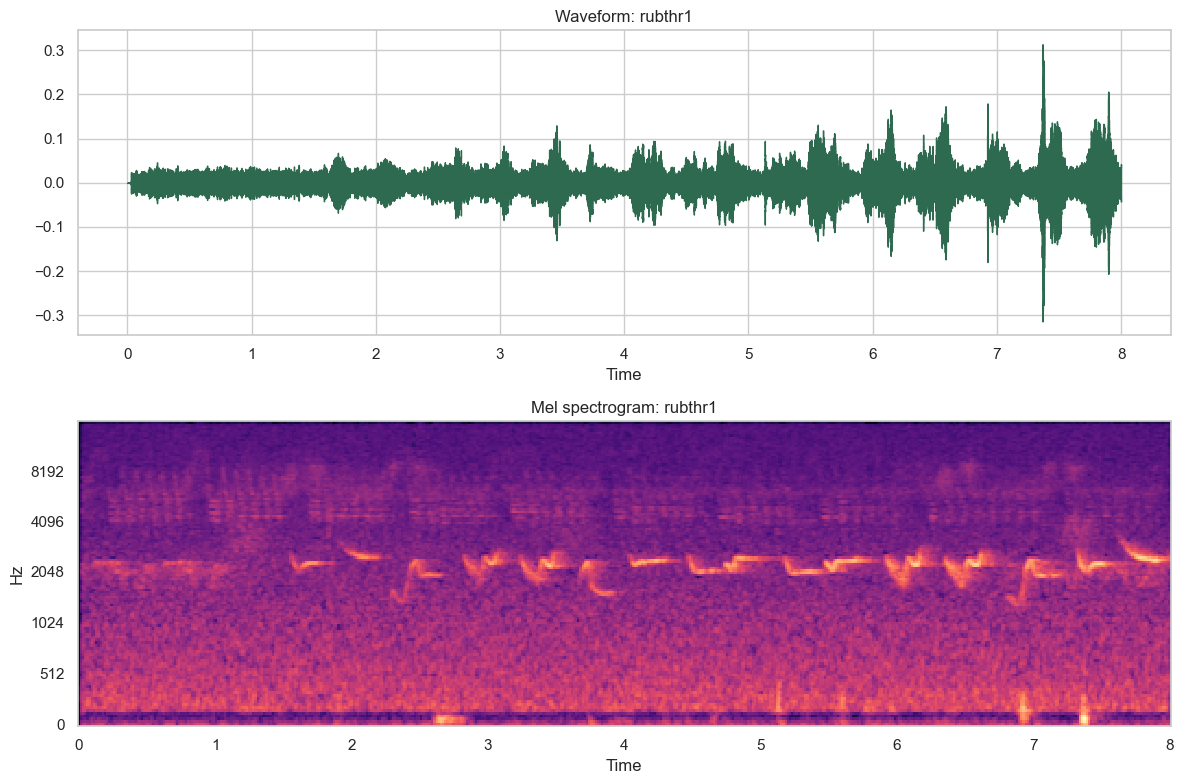

In [11]:
inspect_recording(label_counts.iloc[0]["primary_label"], index=0, duration=8.0)

## Domain notes

Use `docs/DOMAIN_NOTES.md` to track species-level behavioral notes that may affect modeling choices, for example:
- male vs female differences
- song vs call vs alarm behavior
- time-of-day effects
- habitat-specific background noise

## Notes

Record the main findings in `notes.md` and promote reusable logic into `src/` only after it appears more than once.